<a href="https://colab.research.google.com/github/Pavankalyan155/End-to-end-Medical-chatbot-Generative-AI/blob/main/Another_copy_of_MetricMind_Agentic_Semantic_BI_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MetricMind — Agentic Semantic BI Engine
### Enterprise Analytics & Agentic AI

**Objective:** Build a governed conversational BI prototype where an LLM selects approved semantic metrics instead of generating unrestricted SQL.

**Architecture:** Natural Language → Agent → Semantic Query → Governance → Semantic Layer → Warehouse → Analysis → Chart + Audit

This notebook is self-contained and runs with mock corporate data. It also contains production integration templates for dbt, Cube.dev, LangChain/Llama 3, Snowflake/Databricks, and Next.js.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json
import hashlib
import time
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option("display.max_columns", 50)
print("MetricMind initialized")


MetricMind initialized


## 1. Mock Enterprise Warehouse

We create corporate sales data by geography, quarter, and product.

A deliberate **European Q3 margin decline** is introduced through higher material and shipping costs so that the agent can perform root-cause analysis.


In [3]:

import pandas as pd

geographies = ["Europe", "North America", "Asia Pacific"]
products = ["Software", "Hardware", "Services"]
quarters = ["Q1", "Q2", "Q3", "Q4"]

rows = []
for geo in geographies:
    for qi, quarter in enumerate(quarters, 1):
        for product in products:
            geo_factor = {"Europe":1.00, "North America":1.18, "Asia Pacific":0.82}[geo]
            product_factor = {"Software":1.10, "Hardware":1.35, "Services":0.90}[product]
            revenue = 1_000_000 * geo_factor * product_factor * (1 + 0.04*qi)

            material_rate = {"Software":0.18, "Hardware":0.42, "Services":0.12}[product]
            shipping_rate = {"Europe":0.07, "North America":0.04, "Asia Pacific":0.06}[geo]

            if geo == "Europe" and quarter == "Q3":
                material_rate += 0.045
                shipping_rate += 0.055

            material = revenue * material_rate
            shipping = revenue * shipping_rate
            other = revenue * 0.16
            units = int(revenue / {"Software":450, "Hardware":900, "Services":700}[product])

            rows.append([geo, quarter, product, revenue, material, shipping, other, units])

raw_df = pd.DataFrame(rows, columns=[
    "geography","quarter","product","revenue",
    "material_cost","shipping_cost","other_cost","units"
])

raw_df.head()


,geography,quarter,product,revenue,material_cost,shipping_cost,other_cost,units
0,Europe,Q1,Software,1144000.0,205920.0,80080.0,183040.0,2542
1,Europe,Q1,Hardware,1404000.0,589680.0,98280.0,224640.0,1560
2,Europe,Q1,Services,936000.0,112320.0,65520.0,149760.0,1337
3,Europe,Q2,Software,1188000.0,213840.0,83160.0,190080.0,2640
4,Europe,Q2,Hardware,1458000.0,612360.0,102060.0,233280.0,1620


## 2. Data Quality + dbt-Style Transformation

In production these transformations would be dbt staging/mart models. Here pandas reproduces the same logical layers.


In [4]:
def quality_report(df):
    return pd.Series({
        "rows": len(df),
        "null_cells": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "negative_revenue": int((df.revenue < 0).sum())
    })

print(quality_report(raw_df))

fct_sales = raw_df.copy()
fct_sales["total_cost"] = (
    fct_sales["material_cost"] +
    fct_sales["shipping_cost"] +
    fct_sales["other_cost"]
)
fct_sales["gross_profit"] = fct_sales["revenue"] - fct_sales["total_cost"]
fct_sales["margin"] = fct_sales["gross_profit"] / fct_sales["revenue"]
fct_sales.head()


rows                36
null_cells           0
duplicate_rows       0
negative_revenue     0
dtype: int64


,geography,quarter,product,revenue,material_cost,shipping_cost,other_cost,units,total_cost,gross_profit,margin
0,Europe,Q1,Software,1144000.0,205920.0,80080.0,183040.0,2542,469040.0,674960.0,0.59
1,Europe,Q1,Hardware,1404000.0,589680.0,98280.0,224640.0,1560,912600.0,491400.0,0.35
2,Europe,Q1,Services,936000.0,112320.0,65520.0,149760.0,1337,327600.0,608400.0,0.65
3,Europe,Q2,Software,1188000.0,213840.0,83160.0,190080.0,2640,487080.0,700920.0,0.59
4,Europe,Q2,Hardware,1458000.0,612360.0,102060.0,233280.0,1620,947700.0,510300.0,0.35


## 3. Governed Semantic Layer

The semantic layer is the business source of truth.

**Important:** the agent can request a registered metric, but it cannot invent or modify its mathematical definition.

Registered metrics include Revenue, Cost, Material Cost, Shipping Cost, Margin, and Units.


In [5]:
import json

SEMANTIC_LAYER = {
    "revenue": {
        "label": "Revenue",
        "definition": "SUM(revenue)",
        "column": "revenue",
        "format": "currency"
    },
    "cost": {
        "label": "Total Cost",
        "definition": "SUM(material_cost + shipping_cost + other_cost)",
        "format": "currency"
    },
    "material_cost": {
        "label": "Material Cost",
        "definition": "SUM(material_cost)",
        "column": "material_cost",
        "format": "currency"
    },
    "shipping_cost": {
        "label": "Shipping Cost",
        "definition": "SUM(shipping_cost)",
        "column": "shipping_cost",
        "format": "currency"
    },
    "margin": {
        "label": "Margin",
        "definition": "SUM(gross_profit) / SUM(revenue)",
        "format": "percentage"
    },
    "units": {
        "label": "Units",
        "definition": "SUM(units)",
        "column": "units",
        "format": "number"
    }
}

DIMENSIONS = {
    "geography": geographies,
    "quarter": quarters,
    "product": products
}

print(json.dumps(SEMANTIC_LAYER, indent=2))

{
  "revenue": {
    "label": "Revenue",
    "definition": "SUM(revenue)",
    "column": "revenue",
    "format": "currency"
  },
  "cost": {
    "label": "Total Cost",
    "definition": "SUM(material_cost + shipping_cost + other_cost)",
    "format": "currency"
  },
  "material_cost": {
    "label": "Material Cost",
    "definition": "SUM(material_cost)",
    "column": "material_cost",
    "format": "currency"
  },
  "shipping_cost": {
    "label": "Shipping Cost",
    "definition": "SUM(shipping_cost)",
    "column": "shipping_cost",
    "format": "currency"
  },
  "margin": {
    "label": "Margin",
    "definition": "SUM(gross_profit) / SUM(revenue)",
    "format": "percentage"
  },
  "units": {
    "label": "Units",
    "definition": "SUM(units)",
    "column": "units",
    "format": "number"
  }
}


## 4. Semantic Query Engine

Allowed request:

```json
{
  "metrics": ["margin"],
  "dimensions": ["geography"],
  "filters": {"quarter": "Q3"}
}
```

No raw SQL is accepted by the engine.


In [6]:
class SemanticQueryError(Exception):
    pass

def validate_query(query):
    metrics = query.get("metrics", [])
    dimensions = query.get("dimensions", [])
    filters = query.get("filters", {})

    bad_metrics = set(metrics) - set(SEMANTIC_LAYER)
    bad_dimensions = set(dimensions) - set(DIMENSIONS)

    if not metrics:
        raise SemanticQueryError("At least one metric is required.")
    if bad_metrics:
        raise SemanticQueryError(f"Unknown metrics: {sorted(bad_metrics)}")
    if bad_dimensions:
        raise SemanticQueryError(f"Unknown dimensions: {sorted(bad_dimensions)}")

    for dim, value in filters.items():
        if dim not in DIMENSIONS:
            raise SemanticQueryError(f"Filter not allowed: {dim}")
        if value not in DIMENSIONS[dim]:
            raise SemanticQueryError(f"Invalid {dim} value: {value}")

def calculate_metrics(df, metrics):
    revenue = df.revenue.sum()
    cost = df.total_cost.sum()
    profit = df.gross_profit.sum()

    values = {}
    for m in metrics:
        if m == "revenue": values[m] = revenue
        elif m == "cost": values[m] = cost
        elif m == "material_cost": values[m] = df.material_cost.sum()
        elif m == "shipping_cost": values[m] = df.shipping_cost.sum()
        elif m == "margin": values[m] = profit / revenue if revenue else np.nan
        elif m == "units": values[m] = df.units.sum()
    return values

def execute_semantic_query(query):
    validate_query(query)
    work = fct_sales.copy()

    for dim, value in query.get("filters", {}).items():
        work = work[work[dim] == value]

    dims = query.get("dimensions", [])
    if not dims:
        return pd.DataFrame([calculate_metrics(work, query["metrics"])])

    records = []
    for keys, group in work.groupby(dims, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(dims, keys))
        row.update(calculate_metrics(group, query["metrics"]))
        records.append(row)

    return pd.DataFrame(records)


## 5. Governance + Cost Controls

Controls prevent expensive or unsafe exploratory queries:

- metric allow-list
- dimension allow-list
- valid filter values
- maximum dimensions
- maximum result rows
- estimated query-cost budget


In [7]:
MAX_DIMENSIONS = 2
MAX_RESULT_ROWS = 100
MAX_COST_UNITS = 20

def estimate_cost(query):
    return (
        3
        + 5 * len(query.get("dimensions", []))
        + 2 * len(query.get("metrics", []))
        + 3 * max(0, 2 - len(query.get("filters", {})))
    )

def governed_execute(query):
    validate_query(query)

    if len(query.get("dimensions", [])) > MAX_DIMENSIONS:
        raise SemanticQueryError("Rejected: too many dimensions.")

    estimated = estimate_cost(query)
    if estimated > MAX_COST_UNITS:
        raise SemanticQueryError(f"Rejected by cost guard: {estimated} cost units.")

    result = execute_semantic_query(query)

    if len(result) > MAX_RESULT_ROWS:
        raise SemanticQueryError("Rejected: result set too large.")

    return result, estimated


## 6. Deterministic Governance Test

The same semantic request should return the same metric every time. This is a core trust test for enterprise BI.


In [8]:
q = {
    "metrics": ["margin"],
    "dimensions": [],
    "filters": {"geography": "Europe", "quarter": "Q3"}
}

values = [governed_execute(q)[0].iloc[0]["margin"] for _ in range(10)]

print("All results identical:", len(set(values)) == 1)
print(f"Governed Europe Q3 margin: {values[0]:.2%}")


All results identical: True
Governed Europe Q3 margin: 40.94%


## 7. Natural Language → Semantic Query

In production, LangChain + Llama 3 can produce this structured object. The backend must validate it before execution.

For the offline demo, a deterministic parser simulates the LLM orchestration step.


In [9]:
def parse_intent(question):
    q = question.lower()
    metrics = []
    dimensions = []
    filters = {}

    if "margin" in q:
        metrics.append("margin")
    elif "shipping" in q:
        metrics.append("shipping_cost")
    elif "material" in q:
        metrics.append("material_cost")
    elif "revenue" in q or "sales" in q:
        metrics.append("revenue")
    else:
        metrics.append("revenue")

    if "europe" in q or "european" in q:
        filters["geography"] = "Europe"
    elif "north america" in q:
        filters["geography"] = "North America"
    elif "asia" in q:
        filters["geography"] = "Asia Pacific"

    for quarter in quarters:
        if quarter.lower() in q:
            filters["quarter"] = quarter

    if "by geography" in q:
        dimensions.append("geography")
    if "by product" in q:
        dimensions.append("product")
    if "by quarter" in q or "over time" in q:
        dimensions.append("quarter")

    return {"metrics": metrics, "dimensions": dimensions, "filters": filters}

question = "Show me European margin for Q3"
semantic_query = parse_intent(question)
print(json.dumps(semantic_query, indent=2))


{
  "metrics": [
    "margin"
  ],
  "dimensions": [],
  "filters": {
    "geography": "Europe",
    "quarter": "Q3"
  }
}


## 8. Agentic Multi-Step Root-Cause Analysis

For “Why did European margins drop in Q3?”, the agent should not stop at the margin number.

It should:

1. Retrieve Q3 margin.
2. Retrieve Q2 margin.
3. Compare the change.
4. Query cost components.
5. Rank the cost-rate changes.
6. Generate a traceable explanation.


In [10]:
def metric_value(geography, quarter, metric):
    query = {
        "metrics": [metric],
        "dimensions": [],
        "filters": {"geography": geography, "quarter": quarter}
    }
    return governed_execute(query)[0].iloc[0][metric]

def cost_breakdown(geography, quarter):
    query = {
        "metrics": ["revenue", "material_cost", "shipping_cost", "cost"],
        "dimensions": [],
        "filters": {"geography": geography, "quarter": quarter}
    }
    return governed_execute(query)[0].iloc[0].to_dict()

def root_cause_analysis(geography="Europe", current="Q3", previous="Q2"):
    current_margin = metric_value(geography, current, "margin")
    previous_margin = metric_value(geography, previous, "margin")

    c = cost_breakdown(geography, current)
    p = cost_breakdown(geography, previous)

    current_other = c["cost"] - c["material_cost"] - c["shipping_cost"]
    previous_other = p["cost"] - p["material_cost"] - p["shipping_cost"]

    rate_change = pd.Series({
        "material_cost": c["material_cost"]/c["revenue"] - p["material_cost"]/p["revenue"],
        "shipping_cost": c["shipping_cost"]/c["revenue"] - p["shipping_cost"]/p["revenue"],
        "other_cost": current_other/c["revenue"] - previous_other/p["revenue"]
    }).sort_values(ascending=False)

    return {
        "current_margin": current_margin,
        "previous_margin": previous_margin,
        "margin_change": current_margin - previous_margin,
        "current_costs": c,
        "previous_costs": p,
        "rate_change": rate_change
    }

analysis = root_cause_analysis()
analysis


{'current_margin': np.float64(0.4094029850746269),
 'previous_margin': np.float64(0.5094029850746269),
 'margin_change': np.float64(-0.09999999999999998),
 'current_costs': {'revenue': 3752000.0000000005,
  'material_cost': 1146600.0,
  'shipping_cost': 469000.00000000006,
  'cost': 2215920.0},
 'previous_costs': {'revenue': 3618000.0,
  'material_cost': 942840.0,
  'shipping_cost': 253260.00000000006,
  'cost': 1774980.0},
 'rate_change': shipping_cost    5.500000e-02
 material_cost    4.500000e-02
 other_cost      -2.775558e-17
 dtype: float64}

## 9. Executive Explanation

The wording layer is generated from computed results. The numerical facts come from the semantic query engine.


In [11]:
def executive_explanation(a):
    change = a["margin_change"]
    rates = a["rate_change"]
    top = rates.abs().sort_values(ascending=False)

    primary = top.index[0]
    secondary = top.index[1]

    direction = "increased" if change > 0 else "decreased"

    return (
        "MetricMind Executive Analysis\n"
        "-----------------------------\n"
        "Region: Europe | Comparison: Q3 vs Q2\n\n"
        f"European margin {direction} by {abs(change):.2%}.\n"
        f"The largest cost-rate movement was {primary} ({rates[primary]:+.2%} of revenue), "
        f"followed by {secondary} ({rates[secondary]:+.2%}).\n\n"
        "Governed definition: Margin = SUM(gross_profit) / SUM(revenue).\n"
        "The analysis used approved semantic metrics rather than unrestricted SQL."
    )

print(executive_explanation(analysis))


MetricMind Executive Analysis
-----------------------------
Region: Europe | Comparison: Q3 vs Q2

European margin decreased by 10.00%.
The largest cost-rate movement was shipping_cost (+5.50% of revenue), followed by material_cost (+4.50%).

Governed definition: Margin = SUM(gross_profit) / SUM(revenue).
The analysis used approved semantic metrics rather than unrestricted SQL.


## 10. Dynamic Visualization

A production Next.js/Tremor/ECharts frontend can consume the same structured result.


Estimated cost units: 13


,geography,margin
0,Asia Pacific,0.519403
1,Europe,0.409403
2,North America,0.539403


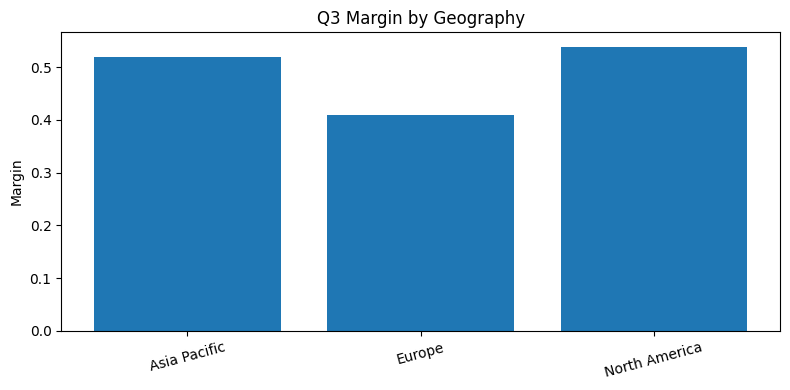

In [12]:
import matplotlib.pyplot as plt

chart_query = {
    "metrics": ["margin"],
    "dimensions": ["geography"],
    "filters": {"quarter": "Q3"}
}

chart_df, cost = governed_execute(chart_query)
print("Estimated cost units:", cost)
display(chart_df)

plt.figure(figsize=(8, 4))
plt.bar(chart_df["geography"], chart_df["margin"])
plt.ylabel("Margin")
plt.title("Q3 Margin by Geography")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 11. Root-Cause Visualization


,Q2,Q3
Material,0.260597,0.305597
Shipping,0.070000,0.125000
Other,0.160000,0.160000


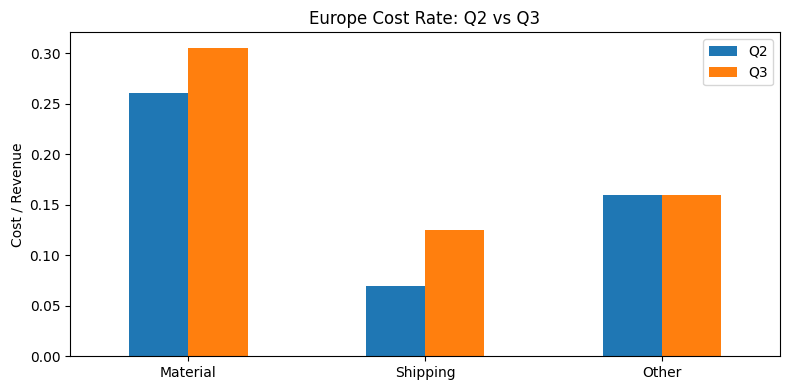

In [13]:
a = analysis
c, p = a["current_costs"], a["previous_costs"]

breakdown = pd.DataFrame({
    "Q2": [
        p["material_cost"]/p["revenue"],
        p["shipping_cost"]/p["revenue"],
        (p["cost"]-p["material_cost"]-p["shipping_cost"])/p["revenue"]
    ],
    "Q3": [
        c["material_cost"]/c["revenue"],
        c["shipping_cost"]/c["revenue"],
        (c["cost"]-c["material_cost"]-c["shipping_cost"])/c["revenue"]
    ]
}, index=["Material", "Shipping", "Other"])

display(breakdown)

breakdown.plot(kind="bar", figsize=(8,4))
plt.ylabel("Cost / Revenue")
plt.title("Europe Cost Rate: Q2 vs Q3")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 12. Audit Trail

Every request should be traceable through:

- request ID
- timestamp
- user/request
- semantic query
- semantic-layer version
- cost estimate
- execution duration
- result hash

This enables reproducibility and governance reviews.


In [14]:
import hashlib
import time
from datetime import datetime
import json
import pandas as pd # Adding pandas import as display(pd.DataFrame([audit])) is used

audit_log = []

def audited_execute(question, query):
    request_id = hashlib.sha256(
        f"{question}-{time.time_ns()}".encode()
    ).hexdigest()[:16]

    start = time.time()
    result, cost = governed_execute(query)
    duration_ms = round((time.time() - start) * 1000, 2)
    result_hash = hashlib.sha256(result.to_json().encode()).hexdigest()

    record = {
        "request_id": request_id,
        "timestamp_utc": datetime.utcnow().isoformat(),
        "question": question,
        "semantic_query": query,
        "semantic_layer_version": "1.0-demo",
        "estimated_cost_units": cost,
        "duration_ms": duration_ms,
        "result_hash": result_hash
    }

    audit_log.append(record)
    return result, record

result, audit = audited_execute(
    "Why did our European margins drop in Q3?",
    q
)

display(result)
print(json.dumps(audit, indent=2, default=str))

/tmp/ipykernel_2684/2663872153.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(),


,margin
0,0.409403


{
  "request_id": "e1832f2c0001da4b",
  "timestamp_utc": "2026-10-02T18:13:03.732983",
  "question": "Why did our European margins drop in Q3?",
  "semantic_query": {
    "metrics": [
      "margin"
    ],
    "dimensions": [],
    "filters": {
      "geography": "Europe",
      "quarter": "Q3"
    }
  },
  "semantic_layer_version": "1.0-demo",
  "estimated_cost_units": 5,
  "duration_ms": 3.16,
  "result_hash": "1051f946fa95101e3c60d8905114e9b7f03df122070800f444e09a0462dec978"
}


## 13. Security Rejection Tests

The agent must not be able to invent metrics, dimensions, or filter values.


In [15]:
bad_queries = {
    "Unknown metric": {
        "metrics": ["fake_revenue"], "dimensions": [], "filters": {}
    },
    "Unknown dimension": {
        "metrics": ["revenue"], "dimensions": ["employee_salary"], "filters": {}
    },
    "Invalid geography": {
        "metrics": ["revenue"], "dimensions": [], "filters": {"geography": "Mars"}
    }
}

for name, bad in bad_queries.items():
    try:
        governed_execute(bad)
        print(name, "FAILED")
    except Exception as e:
        print(name, "PASSED:", e)


Unknown metric PASSED: Unknown metrics: ['fake_revenue']
Unknown dimension PASSED: Unknown dimensions: ['employee_salary']
Invalid geography PASSED: Invalid geography value: Mars


## 14. Production Cube.dev Semantic Model

Illustrative YAML:

```yaml
cube: Sales

sql_table: analytics.fct_sales

measures:
  revenue:
    type: sum
    sql: revenue

  material_cost:
    type: sum
    sql: material_cost

  shipping_cost:
    type: sum
    sql: shipping_cost

  margin:
    type: number
    sql: SUM(gross_profit) / NULLIF(SUM(revenue), 0)

dimensions:
  geography:
    sql: geography
    type: string

  quarter:
    sql: quarter
    type: string

  product:
    sql: product
    type: string
```

The business formula is centralized rather than recreated by each BI client.


## 15. Production LangChain / Llama 3 Tool Contract

The LLM should receive tools similar to:

```text
get_semantic_schema()
query_semantic_layer(metrics, dimensions, filters)
get_metric_definition(metric)
```

It should **not** receive unrestricted Snowflake credentials.

Example tool request:

```json
{
  "metrics": ["margin"],
  "dimensions": ["geography"],
  "filters": {"quarter": "Q3"}
}
```

The API validates this object and calls Cube/dbt Semantic Layer.


## 16. Example Next.js API Response

```json
{
  "answer": "European margin decreased versus Q2...",
  "metric_definition": {
    "name": "Margin",
    "formula": "SUM(gross_profit) / SUM(revenue)"
  },
  "data": [
    {"geography": "Europe", "margin": 0.21},
    {"geography": "North America", "margin": 0.32},
    {"geography": "Asia Pacific", "margin": 0.29}
  ],
  "visualization": {
    "type": "bar",
    "x": "geography",
    "y": "margin"
  },
  "governance": {
    "semantic_layer": "1.0",
    "estimated_cost_units": 8
  },
  "audit": {
    "request_id": "abc123"
  }
}
```


## 17. End-to-End Demo


In [ ]:
question = "Why did our European margins drop in Q3?"

primary_query = {
    "metrics": ["margin"],
    "dimensions": [],
    "filters": {"geography": "Europe", "quarter": "Q3"}
}

primary, audit = audited_execute(question, primary_query)
analysis = root_cause_analysis()

print(executive_explanation(analysis))
print("\nPrimary governed metric:")
display(primary)

print("\nAudit record:")
display(pd.DataFrame([audit]))


MetricMind Executive Analysis
-----------------------------
Region: Europe | Comparison: Q3 vs Q2

European margin decreased by 10.00%.
The largest cost-rate movement was shipping_cost (+5.50% of revenue), followed by material_cost (+4.50%).

Governed definition: Margin = SUM(gross_profit) / SUM(revenue).
The analysis used approved semantic metrics rather than unrestricted SQL.

Primary governed metric:


/tmp/ipykernel_1257/2663872153.py:21: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(),


,margin
0,0.409403



Audit record:


,request_id,timestamp_utc,question,semantic_query,semantic_layer_version,estimated_cost_units,duration_ms,result_hash
0,9b91bf59a738cff6,2026-10-02T17:55:51.471292,Why did our European margins drop in Q3?,"{'metrics': ['margin'], 'dimensions': [], 'fil...",1.0-demo,5,2.29,1051f946fa95101e3c60d8905114e9b7f03df122070800...


## 18. Project Deliverables

### Data & Semantics
- [x] Mock corporate warehouse
- [x] dbt-style transformed fact table
- [x] Revenue / Cost / Margin definitions
- [x] Time / Geography / Product dimensions
- [x] Deterministic semantic query

### Agentic AI
- [x] Natural-language intent parsing
- [x] Semantic query generation
- [x] Multi-step root-cause analysis
- [x] Secondary cost breakdown
- [x] Executive explanation

### Governance
- [x] Metric allow-list
- [x] Dimension validation
- [x] Filter validation
- [x] Query cost limits
- [x] Result limits
- [x] Audit log + result hash

### Production Extensions
- [ ] Snowflake/Databricks deployment
- [ ] dbt models
- [ ] Cube.dev/dbt Semantic Layer deployment
- [ ] LangChain + Llama 3 integration
- [ ] Next.js chat interface
- [ ] Tremor/ECharts visualization
- [ ] RBAC and authentication
- [ ] Query timeout and warehouse budget
- [ ] LLM evaluation and observability


# Final Architecture

```text
Executive Question
       |
       v
+---------------------+
| LangChain + LLM     |
| Orchestrator        |
+----------+----------+
           |
           | Semantic Query
           v
+---------------------+
| Governance Gateway  |
| Validation + Cost   |
| Controls + Audit    |
+----------+----------+
           |
           v
+---------------------+
| Cube / dbt Semantic |
| Layer               |
| Revenue / Margin... |
+----------+----------+
           |
           v
+---------------------+
| Snowflake /         |
| Databricks          |
+----------+----------+
           |
           v
+---------------------+
| JSON + Explanation  |
| Charts + Audit      |
+---------------------+
```

**Core principle:** the LLM is an orchestrator, not the source of truth. Business definitions remain governed in the semantic layer, while the warehouse performs the numerical computation.
